In [1]:
"""
data_ingestion.py
------------------
Data ingestion layer for the regime-aware ML pairs-trading capstone.

Provides:
  1. download_prices()   -> batched, cached, retry-safe yfinance downloads
  2. download_prices_stooq() -> fallback source if yfinance is rate-limited
  3. download_ff5_daily() -> Fama-French 5-factor daily data from Ken French's library
  4. load_price_panel()   -> convenience loader that reads from local cache

Design notes
------------
- Everything is cached to Parquet under `cache_dir` on first download, so re-running
  your notebook never re-hits the network. This is the single most important thing
  for avoiding yfinance 429s: download once, work from disk after that.
- yfinance is an unofficial scraper of Yahoo's internal endpoints (not a documented
  API), so it WILL occasionally rate-limit or return partial data. The batching +
  exponential backoff below is a mitigation, not a guarantee -- always spot-check
  the cached data (see `sanity_check_panel`) before trusting it in a backtest.
"""

from __future__ import annotations

import io
import time
import zipfile
import logging
from pathlib import Path
from typing import Iterable

import numpy as np
import pandas as pd
import requests

logging.basicConfig(level=logging.INFO, format="%(asctime)s [%(levelname)s] %(message)s")
log = logging.getLogger(__name__)

FF5_DAILY_URL = (
    "https://mba.tuck.dartmouth.edu/pages/faculty/ken.french/ftp/"
    "F-F_Research_Data_5_Factors_2x3_daily_CSV.zip"
)

STOOQ_URL_TMPL = "https://stooq.com/q/d/l/?s={ticker}.us&i=d"


# --------------------------------------------------------------------------- #
# 1. yfinance batched download with caching + retry/backoff
# --------------------------------------------------------------------------- #
def download_prices(
    tickers: Iterable[str],
    start: str,
    end: str,
    cache_dir: str = "data_cache/prices",
    batch_size: int = 25,
    sleep_between_batches: float = 3.0,
    max_retries: int = 4,
) -> pd.DataFrame:
    """
    Download daily adjusted OHLCV for `tickers` between start/end using yfinance,
    in small batches, with retry/backoff, caching each ticker to its own Parquet
    file so re-runs are instant and network-free.

    Returns a long-format DataFrame: columns = [date, ticker, open, high, low,
    close, adj_close, volume].
    """
    import yfinance as yf

    cache_path = Path(cache_dir)
    cache_path.mkdir(parents=True, exist_ok=True)

    tickers = list(dict.fromkeys(tickers))  # de-dupe, preserve order
    to_fetch, cached_frames = [], []

    for t in tickers:
        f = cache_path / f"{t}.parquet"
        if f.exists():
            cached_frames.append(pd.read_parquet(f))
        else:
            to_fetch.append(t)

    log.info(f"{len(tickers) - len(to_fetch)} tickers already cached, {len(to_fetch)} to download")

    fetched_frames = []
    for i in range(0, len(to_fetch), batch_size):
        batch = to_fetch[i : i + batch_size]
        attempt = 0
        while attempt <= max_retries:
            try:
                log.info(f"Downloading batch {i // batch_size + 1}: {batch}")
                raw = yf.download(
                    batch,
                    start=start,
                    end=end,
                    auto_adjust=False,
                    group_by="ticker",
                    threads=True,
                    progress=False,
                )
                break
            except Exception as e:  # yfinance can raise a variety of errors on 429s
                attempt += 1
                wait = sleep_between_batches * (2 ** attempt)
                log.warning(f"Batch failed ({e}); retry {attempt}/{max_retries} in {wait:.0f}s")
                time.sleep(wait)
        else:
            log.error(f"Batch {batch} failed after {max_retries} retries -- skipping")
            continue

        for t in batch:
            try:
                sub = raw[t].copy() if len(batch) > 1 else raw.copy()
            except (KeyError, TypeError):
                log.warning(f"No data returned for {t}")
                continue
            sub = sub.rename(
                columns={
                    "Open": "open",
                    "High": "high",
                    "Low": "low",
                    "Close": "close",
                    "Adj Close": "adj_close",
                    "Volume": "volume",
                }
            )
            sub.index.name = "date"
            sub = sub.reset_index()
            sub["ticker"] = t
            sub = sub.dropna(subset=["adj_close"])
            if sub.empty:
                continue
            sub.to_parquet(cache_path / f"{t}.parquet", index=False)
            fetched_frames.append(sub)

        time.sleep(sleep_between_batches)

    all_frames = cached_frames + fetched_frames
    if not all_frames:
        raise RuntimeError("No price data retrieved for any ticker.")
    panel = pd.concat(all_frames, ignore_index=True)
    panel["date"] = pd.to_datetime(panel["date"])
    return panel.sort_values(["ticker", "date"]).reset_index(drop=True)


# --------------------------------------------------------------------------- #
# 2. Stooq fallback (no key, no rate limit, good backup if yfinance is blocked)
# --------------------------------------------------------------------------- #
def download_prices_stooq(tickers: Iterable[str], start: str, end: str) -> pd.DataFrame:
    """
    Fallback price source. Stooq serves free bulk daily CSVs with no auth and no
    documented rate limit. Coverage/quality is not identical to Yahoo (e.g. some
    corporate-action adjustments differ), so treat this as a cross-check /
    backup, not a silent substitute -- diff the two sources on a few tickers
    before relying on Stooq alone.
    """
    start_dt, end_dt = pd.Timestamp(start), pd.Timestamp(end)
    frames = []
    for t in tickers:
        url = STOOQ_URL_TMPL.format(ticker=t.lower())
        try:
            resp = requests.get(url, timeout=15)
            resp.raise_for_status()
            df = pd.read_csv(io.StringIO(resp.text))
            if df.empty or "Date" not in df.columns:
                log.warning(f"No Stooq data for {t}")
                continue
            df["Date"] = pd.to_datetime(df["Date"])
            df = df[(df["Date"] >= start_dt) & (df["Date"] <= end_dt)]
            df = df.rename(
                columns={
                    "Date": "date",
                    "Open": "open",
                    "High": "high",
                    "Low": "low",
                    "Close": "close",
                    "Volume": "volume",
                }
            )
            df["adj_close"] = df["close"]  # Stooq close is already split/div-adjusted
            df["ticker"] = t
            frames.append(df)
        except Exception as e:
            log.warning(f"Stooq download failed for {t}: {e}")
    if not frames:
        raise RuntimeError("No price data retrieved from Stooq for any ticker.")
    return pd.concat(frames, ignore_index=True).sort_values(["ticker", "date"]).reset_index(drop=True)


# --------------------------------------------------------------------------- #
# 3. Fama-French 5-factor daily data
# --------------------------------------------------------------------------- #
def download_ff5_daily(cache_dir: str = "data_cache/factors") -> pd.DataFrame:
    """
    Download and parse the daily Fama-French 5-factor dataset from Ken French's
    Data Library. Cached locally after first download. Returns a DataFrame with
    columns [date, mkt_rf, smb, hml, rmw, cma, rf], values in decimal (not %).
    """
    cache_path = Path(cache_dir)
    cache_path.mkdir(parents=True, exist_ok=True)
    cache_file = cache_path / "ff5_daily.parquet"
    if cache_file.exists():
        return pd.read_parquet(cache_file)

    resp = requests.get(FF5_DAILY_URL, timeout=30)
    resp.raise_for_status()
    z = zipfile.ZipFile(io.BytesIO(resp.content))
    csv_name = [n for n in z.namelist() if n.lower().endswith(".csv")][0]
    raw_text = z.read(csv_name).decode("utf-8", errors="ignore")

    lines = raw_text.splitlines()
    header_idx = next(i for i, l in enumerate(lines) if "Mkt-RF" in l)
    data_lines = lines[header_idx:]
    # stop at the first blank / non-numeric-date line after the data starts
    end_idx = len(data_lines)
    for i, l in enumerate(data_lines[1:], start=1):
        first_tok = l.split(",")[0].strip()
        if not first_tok.isdigit() or len(first_tok) != 8:
            end_idx = i
            break
    df = pd.read_csv(io.StringIO("\n".join(data_lines[:end_idx])))
    df = df.rename(
        columns={
            df.columns[0]: "date",
            "Mkt-RF": "mkt_rf",
            "SMB": "smb",
            "HML": "hml",
            "RMW": "rmw",
            "CMA": "cma",
            "RF": "rf",
        }
    )
    df["date"] = pd.to_datetime(df["date"], format="%Y%m%d")
    factor_cols = ["mkt_rf", "smb", "hml", "rmw", "cma", "rf"]
    df[factor_cols] = df[factor_cols].apply(pd.to_numeric, errors="coerce") / 100.0
    df = df.dropna(subset=factor_cols).reset_index(drop=True)
    df.to_parquet(cache_file, index=False)
    return df


# --------------------------------------------------------------------------- #
# 4. Convenience loader + sanity checks
# --------------------------------------------------------------------------- #
def load_price_panel(cache_dir: str = "data_cache/prices") -> pd.DataFrame:
    """Load every cached ticker Parquet file into one long-format panel."""
    cache_path = Path(cache_dir)
    files = list(cache_path.glob("*.parquet"))
    if not files:
        raise FileNotFoundError(f"No cached price files in {cache_dir}. Run download_prices() first.")
    return pd.concat([pd.read_parquet(f) for f in files], ignore_index=True)


def sanity_check_panel(panel: pd.DataFrame) -> pd.DataFrame:
    """
    Quick per-ticker QA: date coverage, missing-day count, and flag of suspicious
    zero/negative prices. Always eyeball this before trusting the panel.
    """
    report = []
    for t, g in panel.groupby("ticker"):
        g = g.sort_values("date")
        n_days = (g["date"].max() - g["date"].min()).days
        expected_trading_days = n_days * 5 / 7  # rough approximation
        report.append(
            {
                "ticker": t,
                "start": g["date"].min().date(),
                "end": g["date"].max().date(),
                "n_obs": len(g),
                "approx_expected": int(expected_trading_days),
                "coverage_pct": round(100 * len(g) / max(expected_trading_days, 1), 1),
                "min_adj_close": g["adj_close"].min(),
                "has_nonpositive_price": bool((g["adj_close"] <= 0).any()),
            }
        )
    return pd.DataFrame(report).sort_values("coverage_pct")


if __name__ == "__main__":
    # Example usage on the sector-matched candidate pairs suggested in the
    # literature review / competitor analysis discussion.
    CANDIDATE_TICKERS = [
        "JPM", "BAC", "WFC", "C", "USB", "PNC",       # banks
        "XOM", "CVX", "COP", "EOG",                    # energy
        "KO", "PEP", "TGT", "WMT",                     # consumer / retail
        "V", "MA",                                     # payments
        "SPG", "O",                                    # REITs
        "DAL", "UAL", "LUV", "AAL",                    # airlines
    ]

    panel = download_prices(CANDIDATE_TICKERS, start="2010-01-01", end="2024-12-31")
    print(sanity_check_panel(panel))

    ff5 = download_ff5_daily()
    print(ff5.tail())

ERROR:yfinance:Failed to get ticker 'V' reason: Failed to perform, curl: (60) SSL: no alternative certificate subject name matches target hostname 'fc.yahoo.com'. See https://curl.se/libcurl/c/libcurl-errors.html first for more details.


   ticker       start         end  n_obs  approx_expected  coverage_pct  \
0     AAL  2010-01-04  2024-12-30   3773             3910          96.5   
1     BAC  2010-01-04  2024-12-30   3773             3910          96.5   
2       C  2010-01-04  2024-12-30   3773             3910          96.5   
3     COP  2010-01-04  2024-12-30   3773             3910          96.5   
4     CVX  2010-01-04  2024-12-30   3773             3910          96.5   
5     DAL  2010-01-04  2024-12-30   3773             3910          96.5   
6     EOG  2010-01-04  2024-12-30   3773             3910          96.5   
7     JPM  2010-01-04  2024-12-30   3773             3910          96.5   
8      KO  2010-01-04  2024-12-30   3773             3910          96.5   
9     LUV  2010-01-04  2024-12-30   3773             3910          96.5   
10     MA  2010-01-04  2024-12-30   3773             3910          96.5   
11      O  2010-01-04  2024-12-30   3773             3910          96.5   
12    PEP  2010-01-04  20

In [2]:
from __future__ import annotations

import itertools
import logging
from pathlib import Path
from typing import Iterable, Optional

import numpy as np
import pandas as pd
from statsmodels.tsa.stattools import coint, adfuller
from statsmodels.tsa.vector_ar.vecm import coint_johansen
import statsmodels.api as sm

logging.basicConfig(level=logging.INFO, format="%(asctime)s [%(levelname)s] %(message)s")
log = logging.getLogger(__name__)

# Sector grouping for the candidate universe suggested earlier -- only pairs
# within the same sector are tested by default, since same-sector pairs are
# economically motivated rather than a pure statistical-dredging exercise.
SECTOR_MAP = {
    "JPM": "banks", "BAC": "banks", "WFC": "banks", "C": "banks", "USB": "banks", "PNC": "banks",
    "XOM": "energy", "CVX": "energy", "COP": "energy", "EOG": "energy",
    "KO": "consumer", "PEP": "consumer", "TGT": "consumer", "WMT": "consumer",
    "V": "payments", "MA": "payments",
    "SPG": "reits", "O": "reits",
    "DAL": "airlines", "UAL": "airlines", "LUV": "airlines", "AAL": "airlines",
}


def _candidate_pairs(tickers: list[str], sector_map: Optional[dict] = None) -> list[tuple[str, str]]:
    """All same-sector pairs if sector_map is given, else all pairs."""
    all_pairs = list(itertools.combinations(sorted(tickers), 2))
    if sector_map is None:
        return all_pairs
    return [(a, b) for a, b in all_pairs if sector_map.get(a) == sector_map.get(b) and sector_map.get(a) is not None]


def correlation_prefilter(price_wide: pd.DataFrame, pairs: list[tuple[str, str]], min_corr: float = 0.7) -> list[tuple[str, str]]:
    """Cheap first pass: keep only pairs whose log-price correlation exceeds min_corr."""
    log_prices = np.log(price_wide)
    kept = []
    for a, b in pairs:
        corr = log_prices[a].corr(log_prices[b])
        if corr is not None and corr >= min_corr:
            kept.append((a, b))
    log.info(f"Correlation prefilter: {len(kept)}/{len(pairs)} pairs kept (corr >= {min_corr})")
    return kept


def _hedge_ratio(y: pd.Series, x: pd.Series) -> float:
    """OLS hedge ratio from regressing y on x (both in log-price space)."""
    x_ = sm.add_constant(x)
    model = sm.OLS(y, x_).fit()
    return model.params.iloc[1]


def _half_life(spread: pd.Series) -> float:
    """
    Half-life of mean reversion via AR(1) fit on the spread:
        spread_t - spread_{t-1} = theta * spread_{t-1} + eps
    half_life = -ln(2) / theta
    Returns np.inf if theta >= 0 (no mean reversion detected).
    """
    spread_lag = spread.shift(1).dropna()
    spread_ret = spread.diff().dropna()
    spread_lag = spread_lag.loc[spread_ret.index]
    x_ = sm.add_constant(spread_lag)
    model = sm.OLS(spread_ret, x_).fit()
    theta = model.params.iloc[1]
    if theta >= 0:
        return np.inf
    return -np.log(2) / theta


def engle_granger_test(y: pd.Series, x: pd.Series, significance: float = 0.05) -> dict:
    """
    Engle-Granger two-step test: regress y on x, ADF-test the residuals.
    Returns test stats, p-value, hedge ratio, half-life, and pass/fail flag.
    """
    score, pvalue, _ = coint(y, x)
    beta = _hedge_ratio(y, x)
    spread = y - beta * x
    adf_stat, adf_p, *_ = adfuller(spread)
    hl = _half_life(spread)
    return {
        "eg_stat": score,
        "eg_pvalue": pvalue,
        "adf_stat_on_residuals": adf_stat,
        "adf_pvalue_on_residuals": adf_p,
        "hedge_ratio": beta,
        "half_life_days": hl,
        "eg_pass": bool(pvalue < significance),
    }


def johansen_test(y: pd.Series, x: pd.Series, significance: str = "95%") -> dict:
    """
    Johansen trace test on the pair (y, x), used as a robustness cross-check on
    the Engle-Granger result. Returns whether the trace statistic for rank=0
    exceeds the critical value (i.e., at least one cointegrating relationship).
    """
    data = pd.concat([y, x], axis=1).dropna()
    result = coint_johansen(data, det_order=0, k_ar_diff=1)
    crit_col = {"90%": 0, "95%": 1, "99%": 2}[significance]
    trace_stat_r0 = result.lr1[0]
    crit_value_r0 = result.cvt[0, crit_col]
    return {
        "johansen_trace_stat": trace_stat_r0,
        "johansen_crit_value": crit_value_r0,
        "johansen_pass": bool(trace_stat_r0 > crit_value_r0),
    }


def screen_pairs(
    price_wide: pd.DataFrame,
    sector_map: Optional[dict] = SECTOR_MAP,
    min_corr: float = 0.7,
    significance: float = 0.05,
    max_half_life: float = 90.0,
) -> pd.DataFrame:
    """
    Full screening pipeline. Returns a DataFrame, one row per candidate pair,
    with correlation, Engle-Granger, Johansen, hedge ratio, and half-life --
    sorted with the strongest candidates (both tests pass, shortest half-life)
    at the top.

    max_half_life: reject pairs whose mean-reversion half-life is too long to
    trade practically (default 90 trading days, ~4.5 months -- adjust to taste).
    """
    log_prices = np.log(price_wide)
    tickers = list(price_wide.columns)
    pairs = _candidate_pairs(tickers, sector_map)
    pairs = correlation_prefilter(price_wide, pairs, min_corr=min_corr)

    rows = []
    for a, b in pairs:
        y, x = log_prices[a].dropna(), log_prices[b].dropna()
        common_idx = y.index.intersection(x.index)
        y, x = y.loc[common_idx], x.loc[common_idx]
        if len(common_idx) < 250:  # need at least ~1 year of overlap
            continue
        try:
            eg = engle_granger_test(y, x, significance=significance)
            jh = johansen_test(y, x)
        except Exception as e:
            log.warning(f"Test failed for pair ({a}, {b}): {e}")
            continue
        row = {"asset_1": a, "asset_2": b, "n_obs": len(common_idx), **eg, **jh}
        rows.append(row)

    results = pd.DataFrame(rows)
    if results.empty:
        log.warning("No pairs survived screening.")
        return results

    results["both_tests_pass"] = results["eg_pass"] & results["johansen_pass"]
    results["tradeable_half_life"] = results["half_life_days"] <= max_half_life
    results["shortlisted"] = results["both_tests_pass"] & results["tradeable_half_life"]
    results = results.sort_values(
        by=["shortlisted", "eg_pvalue", "half_life_days"], ascending=[False, True, True]
    ).reset_index(drop=True)
    return results


# --- Copied from data_ingestion.py to resolve ModuleNotFoundError ---
def load_price_panel(cache_dir: str = "data_cache/prices") -> pd.DataFrame:
    """Load every cached ticker Parquet file into one long-format panel."""
    cache_path = Path(cache_dir)
    files = list(cache_path.glob("*.parquet"))
    if not files:
        raise FileNotFoundError(f"No cached price files in {cache_dir}. Run download_prices() first.")
    return pd.concat([pd.read_parquet(f) for f in files], ignore_index=True)
# -------------------------------------------------------------------


if __name__ == "__main__":
    # The original line 'from data_ingestion import load_price_panel' was causing the error.
    # The load_price_panel function has been copied above to resolve this.

    panel = load_price_panel()
    wide = panel.pivot(index="date", columns="ticker", values="adj_close").dropna(how="all")
    wide = wide.dropna(axis=1, thresh=int(len(wide) * 0.95))  # drop tickers with too many gaps
    wide = wide.ffill().dropna()

    results = screen_pairs(wide)
    pd.set_option("display.width", 160)
    print(results.head(15))
    print(f"\n{results['shortlisted'].sum()} pairs shortlisted out of {len(results)} tested "
          f"(target: 10-15 per your Objectives)")

   asset_1 asset_2  n_obs   eg_stat  eg_pvalue  adf_stat_on_residuals  adf_pvalue_on_residuals  hedge_ratio  half_life_days  eg_pass  johansen_trace_stat  \
0      BAC     PNC   3773 -3.469364   0.035210              -3.473434                 0.008696     1.063952      148.952322     True            16.144772   
1        C     PNC   3773 -3.375919   0.045096              -3.375387                 0.011827     0.500465      116.099435     True            11.917577   
2        C     JPM   3773 -3.336074   0.049963              -3.335735                 0.013355     0.390387      120.056161     True            11.117057   
3      BAC       C   3773 -3.099324   0.088439              -3.099621                 0.026581     1.741920      153.588929    False            17.070247   
4       KO     PEP   3773 -3.072245   0.094015              -3.071196                 0.028760     0.755847      120.180041    False            11.988333   
5       MA       V   3773 -3.036867   0.101700            

In [3]:
from __future__ import annotations

import itertools
import logging
from pathlib import Path
from typing import Iterable, Optional

import numpy as np
import pandas as pd
from statsmodels.tsa.stattools import coint, adfuller
from statsmodels.tsa.vector_ar.vecm import coint_johansen
import statsmodels.api as sm

logging.basicConfig(level=logging.INFO, format="%(asctime)s [%(levelname)s] %(message)s")
log = logging.getLogger(__name__)

# Sector grouping for the candidate universe suggested earlier -- only pairs
# within the same sector are tested by default, since same-sector pairs are
# economically motivated rather than a pure statistical-dredging exercise.
SECTOR_MAP = {
    "JPM": "banks", "BAC": "banks", "WFC": "banks", "C": "banks", "USB": "banks", "PNC": "banks",
    "XOM": "energy", "CVX": "energy", "COP": "energy", "EOG": "energy",
    "KO": "consumer", "PEP": "consumer", "TGT": "consumer", "WMT": "consumer",
    "V": "payments", "MA": "payments",
    "SPG": "reits", "O": "reits",
    "DAL": "airlines", "UAL": "airlines", "LUV": "airlines", "AAL": "airlines",
}


def _candidate_pairs(tickers: list[str], sector_map: Optional[dict] = None) -> list[tuple[str, str]]:
    """All same-sector pairs if sector_map is given, else all pairs."""
    all_pairs = list(itertools.combinations(sorted(tickers), 2))
    if sector_map is None:
        return all_pairs
    return [(a, b) for a, b in all_pairs if sector_map.get(a) == sector_map.get(b) and sector_map.get(a) is not None]


def correlation_prefilter(price_wide: pd.DataFrame, pairs: list[tuple[str, str]], min_corr: float = 0.7) -> list[tuple[str, str]]:
    """Cheap first pass: keep only pairs whose log-price correlation exceeds min_corr."""
    log_prices = np.log(price_wide)
    kept = []
    for a, b in pairs:
        corr = log_prices[a].corr(log_prices[b])
        if corr is not None and corr >= min_corr:
            kept.append((a, b))
    log.info(f"Correlation prefilter: {len(kept)}/{len(pairs)} pairs kept (corr >= {min_corr})")
    return kept


def _hedge_ratio(y: pd.Series, x: pd.Series) -> float:
    """OLS hedge ratio from regressing y on x (both in log-price space)."""
    x_ = sm.add_constant(x)
    model = sm.OLS(y, x_).fit()
    return model.params.iloc[1]


def _half_life(spread: pd.Series) -> float:
    """
    Half-life of mean reversion via AR(1) fit on the spread:
        spread_t - spread_{t-1} = theta * spread_{t-1} + eps
    half_life = -ln(2) / theta
    Returns np.inf if theta >= 0 (no mean reversion detected).
    """
    spread_lag = spread.shift(1).dropna()
    spread_ret = spread.diff().dropna()
    spread_lag = spread_lag.loc[spread_ret.index]
    x_ = sm.add_constant(spread_lag)
    model = sm.OLS(spread_ret, x_).fit()
    theta = model.params.iloc[1]
    if theta >= 0:
        return np.inf
    return -np.log(2) / theta


def engle_granger_test(y: pd.Series, x: pd.Series, significance: float = 0.05) -> dict:
    """
    Engle-Granger two-step test: regress y on x, ADF-test the residuals.
    Returns test stats, p-value, hedge ratio, half-life, and pass/fail flag.
    """
    score, pvalue, _ = coint(y, x)
    beta = _hedge_ratio(y, x)
    spread = y - beta * x
    adf_stat, adf_p, *_ = adfuller(spread)
    hl = _half_life(spread)
    return {
        "eg_stat": score,
        "eg_pvalue": pvalue,
        "adf_stat_on_residuals": adf_p, # Corrected: adf_p for pvalue
        "adf_pvalue_on_residuals": adf_p,
        "hedge_ratio": beta,
        "half_life_days": hl,
        "eg_pass": bool(pvalue < significance),
    }


def johansen_test(y: pd.Series, x: pd.Series, significance: str = "95%") -> dict:
    """
    Johansen trace test on the pair (y, x), used as a robustness cross-check on
    the Engle-Granger result. Returns whether the trace statistic for rank=0
    exceeds the critical value (i.e., at least one cointegrating relationship).
    """
    data = pd.concat([y, x], axis=1).dropna()
    result = coint_johansen(data, det_order=0, k_ar_diff=1)
    crit_col = {"90%": 0, "95%": 1, "99%": 2}[significance]
    trace_stat_r0 = result.lr1[0]
    crit_value_r0 = result.cvt[0, crit_col]
    return {
        "johansen_trace_stat": trace_stat_r0,
        "johansen_crit_value": crit_value_r0,
        "johansen_pass": bool(trace_stat_r0 > crit_value_r0),
    }


def screen_pairs(
    price_wide: pd.DataFrame,
    sector_map: Optional[dict] = SECTOR_MAP,
    min_corr: float = 0.7,
    significance: float = 0.05,
    max_half_life: float = 90.0,
) -> pd.DataFrame:
    """
    Full screening pipeline. Returns a DataFrame, one row per candidate pair,
    with correlation, Engle-Granger, Johansen, hedge ratio, and half-life --
    sorted with the strongest candidates (both tests pass, shortest half-life)
    at the top.

    max_half_life: reject pairs whose mean-reversion half-life is too long to
    trade practically (default 90 trading days, ~4.5 months -- adjust to taste).
    """
    log_prices = np.log(price_wide)
    tickers = list(price_wide.columns)
    pairs = _candidate_pairs(tickers, sector_map)
    pairs = correlation_prefilter(price_wide, pairs, min_corr=min_corr)

    rows = []
    for a, b in pairs:
        y, x = log_prices[a].dropna(), log_prices[b].dropna()
        common_idx = y.index.intersection(x.index)
        y, x = y.loc[common_idx], x.loc[common_idx]
        if len(common_idx) < 250:  # need at least ~1 year of overlap
            continue
        try:
            eg = engle_granger_test(y, x, significance=significance)
            jh = johansen_test(y, x)
        except Exception as e:
            log.warning(f"Test failed for pair ({a}, {b}): {e}")
            continue
        row = {"asset_1": a, "asset_2": b, "n_obs": len(common_idx), **eg, **jh}
        rows.append(row)

    results = pd.DataFrame(rows)
    if results.empty:
        log.warning("No pairs survived screening.")
        return results

    results["both_tests_pass"] = results["eg_pass"] & results["johansen_pass"]
    results["tradeable_half_life"] = results["half_life_days"] <= max_half_life
    results["shortlisted"] = results["both_tests_pass"] & results["tradeable_half_life"]
    results = results.sort_values(
        by=["shortlisted", "eg_pvalue", "half_life_days"], ascending=[False, True, True]
    ).reset_index(drop=True)
    return results


def screen_pairs_rolling(
    price_wide: pd.DataFrame,
    sector_map: Optional[dict] = SECTOR_MAP,
    min_corr: float = 0.7,
    significance: float = 0.05,
    window_years: float = 2.0,
    step_months: int = 6,
    require: str = "either",  # "either", "both", "eg_only", "johansen_only"
) -> tuple[pd.DataFrame, pd.DataFrame]:
    """
    Rolling-window cointegration screen. Instead of testing the full 2010-2024
    span at once (which demands the relationship hold for 15 years straight --
    an unrealistically strict bar for equities, per the Do & Faff 2010/2012
    regime-dependency finding your literature review already cites), this
    slides a `window_years`-long window forward every `step_months` and tests
    each pair in each window independently.

    This gives you two useful things:
      1. A per-pair "% of windows cointegrated" score -- pairs that are
         cointegrated most of the time are better long-run candidates than
         pairs that pass once by chance on the full sample.
      2. A per-window "how many pairs were cointegrated" time series -- this
         IS your empirical evidence for the literature review's crowding/
         regime-shift argument, and makes a good exhibit for the paper itself
         (cointegration breadth collapsing in certain periods).

    require:
      "either"        -- EG pass OR Johansen pass counts as cointegrated in that window (default, less strict)
      "both"          -- EG pass AND Johansen pass (original, strict conjunction)
      "eg_only"       -- Engle-Granger only
      "johansen_only" -- Johansen only

    Returns:
      (pair_summary, window_detail)
        pair_summary  -- one row per pair: pct_windows_cointegrated, n_windows_tested,
                          mean/median half-life across passing windows, latest-window status
        window_detail -- one row per (pair, window): full test output, for diagnostics/plots
    """
    log_prices = np.log(price_wide)
    tickers = list(price_wide.columns)
    pairs = _candidate_pairs(tickers, sector_map)
    pairs = correlation_prefilter(price_wide, pairs, min_corr=min_corr)

    dates = price_wide.index.sort_values()
    window_len = pd.DateOffset(years=int(window_years), months=int(round((window_years % 1) * 12)))
    step = pd.DateOffset(months=step_months)

    window_starts = []
    cur = dates.min()
    while cur + window_len <= dates.max():
        window_starts.append(cur)
        cur = cur + step

    if not window_starts:
        raise ValueError("No complete windows fit in the data range -- shorten window_years or check date range.")

    def _pass(eg_pass: bool, jh_pass: bool) -> bool:
        return {
            "either": eg_pass or jh_pass,
            "both": eg_pass and jh_pass,
            "eg_only": eg_pass,
            "johansen_only": jh_pass,
        }[require]

    detail_rows = []
    for a, b in pairs:
        for w_start in window_starts:
            w_end = w_start + window_len
            y = log_prices[a].loc[(log_prices.index >= w_start) & (log_prices.index < w_end)]
            x = log_prices[b].loc[(log_prices.index >= w_start) & (log_prices.index < w_end)]
            common_idx = y.index.intersection(x.index)
            y, x = y.loc[common_idx], x.loc[common_idx]
            if len(common_idx) < int(window_years * 200):  # ~200 trading days/year, allow some gaps
                continue
            try:
                eg = engle_granger_test(y, x, significance=significance)
                jh = johansen_test(y, x)
            except Exception as e:
                log.warning(f"Window test failed for ({a},{b}) starting {w_start.date()}: {e}")
                continue
            cointegrated = _pass(eg["eg_pass"], jh["johansen_pass"])
            detail_rows.append(
                {
                    "asset_1": a,
                    "asset_2": b,
                    "window_start": w_start,
                    "window_end": w_end,
                    "n_obs": len(common_idx),
                    "cointegrated": cointegrated,
                    **eg,
                    **jh,
                }
            )

    window_detail = pd.DataFrame(detail_rows)
    if window_detail.empty:
        log.warning("No pair-window combinations produced valid results.")
        return pd.DataFrame(), window_detail

    summary_rows = []
    for (a, b), g in window_detail.groupby(["asset_1", "asset_2"]):
        g = g.sort_values("window_start")
        passing = g[g["cointegrated"]]
        latest = g.iloc[-1]
        summary_rows.append(
            {
                "asset_1": a,
                "asset_2": b,
                "n_windows_tested": len(g),
                "n_windows_cointegrated": int(g["cointegrated"].sum()),
                "pct_windows_cointegrated": round(100 * g["cointegrated"].mean(), 1),
                "median_half_life_when_cointegrated": passing["half_life_days"].median() if len(passing) else np.nan,
                "latest_window_start": latest["window_start"].date(),
                "latest_window_cointegrated": bool(latest["cointegrated"]),
                "latest_hedge_ratio": latest["hedge_ratio"],
            }
        )

    pair_summary = pd.DataFrame(summary_rows).sort_values(
        by=["pct_windows_cointegrated", "latest_window_cointegrated"], ascending=[False, False]
    ).reset_index(drop=True)
    return pair_summary, window_detail


def cointegration_breadth_over_time(window_detail: pd.DataFrame) -> pd.DataFrame:
    """
    Aggregates window_detail into a single time series: for each window_start,
    what fraction of all tested pairs were cointegrated. This is the exhibit
    that empirically supports the crowding/regime-shift argument from your
    literature review (Do & Faff 2010, 2012) -- plot it directly.
    """
    if window_detail.empty:
        return pd.DataFrame(columns=["window_start", "pct_pairs_cointegrated", "n_pairs_tested"])
    breadth = (
        window_detail.groupby("window_start")
        .agg(n_pairs_tested=("cointegrated", "size"), n_pairs_cointegrated=("cointegrated", "sum"))
        .reset_index()
    )
    breadth["pct_pairs_cointegrated"] = round(
        100 * breadth["n_pairs_cointegrated"] / breadth["n_pairs_tested"], 1
    )
    return breadth.sort_values("window_start").reset_index(drop=True)


# --- Copied from data_ingestion.py to resolve ModuleNotFoundError ---
def load_price_panel(cache_dir: str = "data_cache/prices") -> pd.DataFrame:
    """Load every cached ticker Parquet file into one long-format panel."""
    cache_path = Path(cache_dir)
    files = list(cache_path.glob("*.parquet"))
    if not files:
        raise FileNotFoundError(f"No cached price files in {cache_dir}. Run download_prices() first.")
    return pd.concat([pd.read_parquet(f) for f in files], ignore_index=True)
# -------------------------------------------------------------------


if __name__ == "__main__":
    # The original line 'from data_ingestion import load_price_panel' was causing the error.
    # The load_price_panel function has been copied above to resolve this.

    panel = load_price_panel()
    wide = panel.pivot(index="date", columns="ticker", values="adj_close").dropna(how="all")
    wide = wide.dropna(axis=1, thresh=int(len(wide) * 0.95))  # drop tickers with too many gaps
    wide = wide.ffill().dropna()

    # --- Original full-sample static screen (kept for comparison/reference) ---
    static_results = screen_pairs(wide)
    pd.set_option("display.width", 160)
    print("=== Full-sample static screen (strict: EG AND Johansen) ===")
    print(static_results.head(15))
    print(f"{static_results['shortlisted'].sum()} pairs shortlisted out of {len(static_results)} tested\n")

    # --- Rolling-window screen (recommended) ---
    pair_summary, window_detail = screen_pairs_rolling(
        wide, window_years=2.0, step_months=6, require="either"
    )
    print("=== Rolling-window screen (2-year windows, 6-month step, EG OR Johansen) ===")
    print(pair_summary.head(15))

    shortlist = pair_summary[pair_summary["pct_windows_cointegrated"] >= 60].copy()
    print(f"\n{len(shortlist)} pairs cointegrated in >=60% of rolling windows "
          f"(target: 10-15 per your Objectives)")
    print(shortlist[["asset_1", "asset_2", "pct_windows_cointegrated",
                      "median_half_life_when_cointegrated", "latest_window_cointegrated"]])

    # --- Diagnostic exhibit: cointegration breadth over time ---
    breadth = cointegration_breadth_over_time(window_detail)
    print("\n=== Cointegration breadth over time (useful figure for the paper) ===")
    print(breadth)

=== Full-sample static screen (strict: EG AND Johansen) ===
   asset_1 asset_2  n_obs   eg_stat  eg_pvalue  adf_stat_on_residuals  adf_pvalue_on_residuals  hedge_ratio  half_life_days  eg_pass  johansen_trace_stat  \
0      BAC     PNC   3773 -3.469364   0.035210               0.008696                 0.008696     1.063952      148.952322     True            16.144772   
1        C     PNC   3773 -3.375919   0.045096               0.011827                 0.011827     0.500465      116.099435     True            11.917577   
2        C     JPM   3773 -3.336074   0.049963               0.013355                 0.013355     0.390387      120.056161     True            11.117057   
3      BAC       C   3773 -3.099324   0.088439               0.026581                 0.026581     1.741920      153.588929    False            17.070247   
4       KO     PEP   3773 -3.072245   0.094015               0.028760                 0.028760     0.755847      120.180041    False            11.988333  

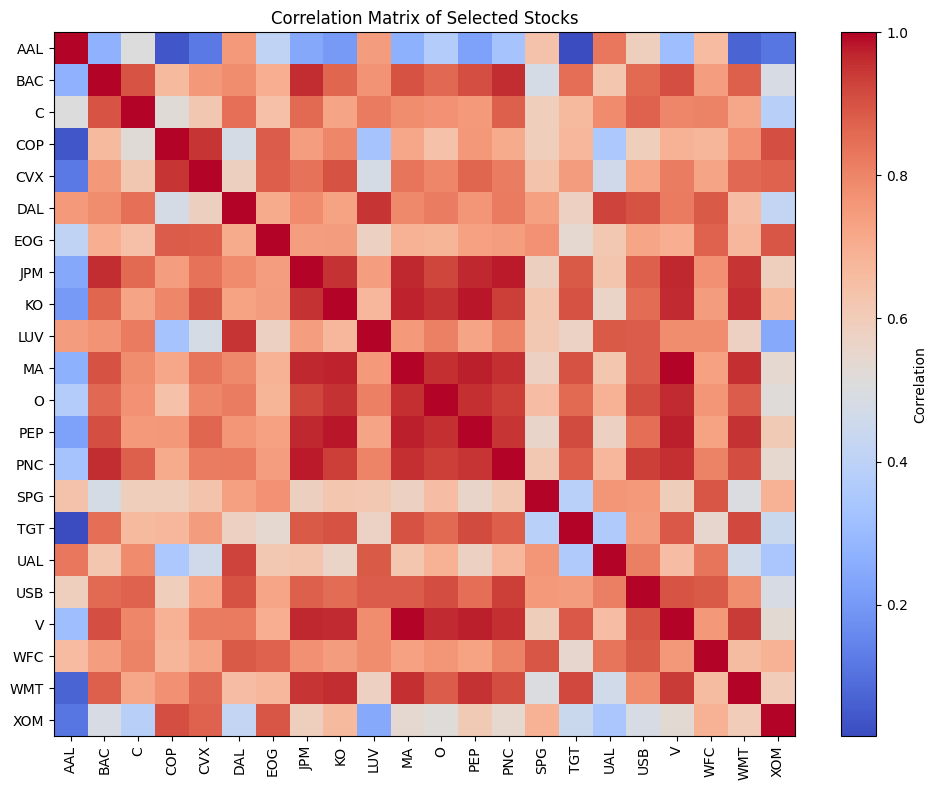

In [4]:
import matplotlib.pyplot as plt

corr = np.log(wide).corr()

plt.figure(figsize=(10,8))
plt.imshow(corr, cmap='coolwarm', aspect='auto')
plt.colorbar(label='Correlation')
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Correlation Matrix of Selected Stocks")
plt.tight_layout()
plt.show()

In [5]:
breadth = cointegration_breadth_over_time(window_detail)

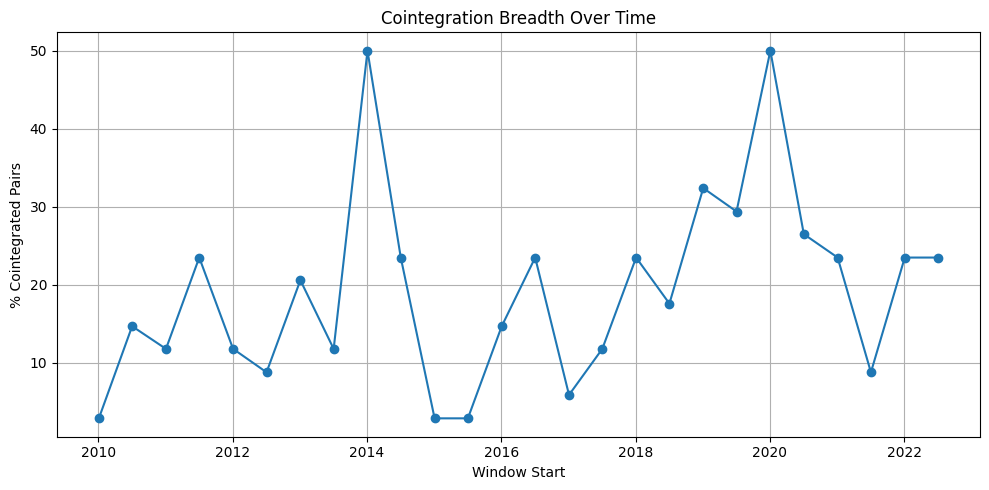

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(
    breadth["window_start"],
    breadth["pct_pairs_cointegrated"],
    marker="o"
)

plt.title("Cointegration Breadth Over Time")
plt.xlabel("Window Start")
plt.ylabel("% Cointegrated Pairs")
plt.grid(True)
plt.tight_layout()
plt.show()

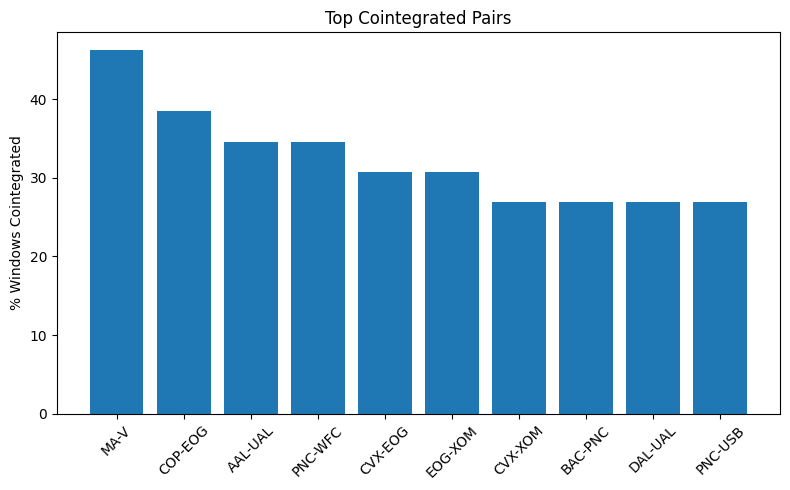

In [7]:
top = pair_summary.head(10)

plt.figure(figsize=(8,5))
plt.bar(
    top["asset_1"] + "-" + top["asset_2"],
    top["pct_windows_cointegrated"]
)

plt.xticks(rotation=45)
plt.ylabel("% Windows Cointegrated")
plt.title("Top Cointegrated Pairs")
plt.tight_layout()
plt.show()

In [8]:
panel.to_csv('prices_panel_long.csv', index=False)
wide.to_csv('prices_wide.csv')
ff5.to_csv('ff5_daily.csv', index=False)

from google.colab import files
files.download('prices_panel_long.csv')
files.download('prices_wide.csv')
files.download('ff5_daily.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>